## Library Imports

In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense, Dropout

from tensorflow.keras.layers import Input, Bidirectional, Dense, LSTM, RepeatVector, TimeDistributed, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Union, Optional
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


from pathlib import Path
import joblib
import os

from typing import List, Tuple, Dict, Union, Optional

### Data Preparation

This function is responsible for segmenting the dataset into training, validation, and test sets based on a defined condition (train_test). The utilization of StandardScaler ensures proper normalization, which is crucial for neural network models. The feature selection (feature_columns) highlights the identification of the most relevant sensors and parameters.

In [31]:
def prepare_data(merged_df):
    # Séparer les données train et test
    train_data = merged_df[merged_df['train_test'] == 'train']
    test_data = merged_df[merged_df['train_test'] == 'prediction']

    # Garder uniquement les données normales pour l'entraînement
    normal_train_data = train_data[train_data['status_type_id'].isin([0, 2])]

    # Sélectionner les colonnes de features
    feature_columns = ['sensor_50', 'wind_speed_3_avg', 'wind_speed_4_avg', 'sensor_45',
                       'power_30_avg', 'reactive_power_28_avg', 'reactive_power_27_avg',
                       'sensor_24_avg', 'sensor_18_avg', 'sensor_18_min', 'sensor_25_avg',
                       'sensor_52_min', 'sensor_23_avg', 'sensor_52_avg',
                       'sensor_44', 'sensor_51', 'sensor_48', 'sensor_5_max', 'power_29_avg']

    # Définir une proportion pour validation (ex: 20%)
    val_ratio = 0.2
    split_index = int(len(normal_train_data) * (1 - val_ratio))

    # Split séquentiel au lieu de shuffle
    train_data, val_data = normal_train_data.iloc[:split_index], normal_train_data.iloc[split_index:]

    # Normalisation
    scaler = StandardScaler()
    normal_train_scaled = scaler.fit_transform(train_data[feature_columns])
    val_scaled = scaler.transform(val_data[feature_columns])
    test_scaled = scaler.transform(test_data[feature_columns])

    return normal_train_scaled, val_scaled, test_scaled, val_data, test_data, feature_columns, scaler

## Sequence Generation

Implementation of Data Batching for Training:
A memory-efficient generator is applied to produce mini-batches (batch_size) of time-series sequences, facilitating the training process of the autoencoder. The absence of shuffling maintains the chronological order of the data, which is essential for anomaly detection in sequential models.



In [ ]:
# Memory-efficient sequence generator
def sequence_generator(data, seq_length, batch_size):
    n_samples = len(data) - seq_length
    indices = np.random.permutation(n_samples)

    for idx in range(0, n_samples, batch_size):
        batch_idx = indices[idx:min(idx + batch_size, n_samples)]
        X_batch = np.array([data[i:i + seq_length] for i in batch_idx])

        yield X_batch, X_batch  # Autoencoder reconstruction

## LSTM Autoencoder Model

Design and Implementation of Neural Network Architecture :
This function constructs a bidirectional LSTM-based autoencoder (Bidirectional LSTM). The application of BatchNormalization, Dropout, and Dense layers enhances regularization and model stability. The output layer (TimeDistributed(Dense(..., activation='sigmoid'))) ensures that the reconstructed values remain within a controlled range.

In [ ]:
def build_model(input_dim, seq_length, encoding_dim=16):

    inputs = Input(shape=(seq_length, input_dim))

    # Encoder
    x = Bidirectional(LSTM(64, activation='relu', return_sequences=True))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x = Bidirectional(LSTM(32, activation='relu', return_sequences=False))(x)
    x = BatchNormalization()(x)

    # Bottleneck
    bottleneck = Dense(encoding_dim, activation='relu')(x)

    # Decoder
    x = RepeatVector(seq_length)(bottleneck)
    x = Dense(encoding_dim, activation='relu')(x)  # Ajout d'une couche Dense intermédiaire
    x = Bidirectional(LSTM(32, activation='relu', return_sequences=True))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x = Bidirectional(LSTM(64, activation='relu', return_sequences=True))(x)
    x = BatchNormalization()(x)

    outputs = TimeDistributed(Dense(input_dim, activation='sigmoid'))(x)  # Ajout de sigmoid pour normaliser les sorties

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    return model

## Reconstruction Error Calculation

This function computes the reconstruction errors by measuring the deviations between input and output values, which is critical for anomaly identification. The inclusion of a try-except block demonstrates the implementation of robust error handling to prevent disruptions in execution.

In [ ]:
def calculate_reconstruction_errors(model, data, seq_length, batch_size=64):

    errors = []
    n_samples = len(data) - seq_length + 1  # Nombre de séquences exploitables

    for i in range(0, n_samples, batch_size):
        end_idx = min(i + batch_size, n_samples)

        # Construction du batch (batch_size, seq_length, input_dim)
        X_batch = np.stack([data[j:j+seq_length] for j in range(i, end_idx)])

        try:
            # Prédiction du modèle
            X_pred_batch = model.predict(X_batch, verbose=0)

            # Calcul de l'erreur MSE pour chaque séquence
            batch_errors = np.mean(np.square(X_batch - X_pred_batch), axis=(1, 2))
            errors.extend(batch_errors)

        except Exception as e:
            print(f"Erreur lors de la prédiction du batch {i}-{end_idx}: {e}")

        # Affichage de la progression
        if i % (batch_size * 10) == 0:
            print(f"Processed {i}/{n_samples} sequences")

    return np.array(errors)

## Application of a Scoring Metric for Model Assessment

In [13]:
## AnomalyEvent
class AnomalyEvent:
    """Classe représentant un événement d'anomalie avec ses caractéristiques temporelles et prédictions."""

    def __init__(self, start_idx: int, end_idx: int, timestamps: List, predictions: List[int], ground_truth: List[int]):
        """
        Initialise un événement d'anomalie.

        Args:
            start_idx: Indice de début de l'événement
            end_idx: Indice de fin de l'événement
            timestamps: Liste des horodatages de l'événement
            predictions: Liste des prédictions (0 ou 1) pour chaque horodatage
            ground_truth: Liste des vérités terrain (0 ou 1) pour chaque horodatage
        """
        self.start_idx = start_idx
        self.end_idx = end_idx
        self.timestamps = timestamps
        self.predictions = predictions
        self.ground_truth = ground_truth
        self.length = end_idx - start_idx + 1

    def is_detected(self) -> bool:
        """Vérifie si l'événement est détecté (au moins une prédiction positive)."""
        return 1 in self.predictions



##EventDetector
class EventDetector:
    """Classe utilitaire pour détecter des événements d'anomalie dans une série temporelle."""

    @staticmethod
    def detect_events(df: pd.DataFrame, status_column: str = 'status_id',
                      normal_value: str = 'normal', predictions_column: str = 'anomaly',
                      time_column: str = 'timestamp', min_gap: int = 3) -> List[AnomalyEvent]:
        """
        Détecte des événements d'anomalie dans une série temporelle.

        Args:
            df: DataFrame contenant les données
            status_column: Nom de la colonne contenant le statut (normal ou anormal)
            normal_value: Valeur indiquant un comportement normal
            predictions_column: Nom de la colonne contenant les prédictions d'anomalie
            time_column: Nom de la colonne contenant les horodatages
            min_gap: Écart minimal entre deux événements distincts

        Returns:
            Liste des événements d'anomalie détectés
        """
        # Convertir le statut en valeurs binaires (0 pour normal, 1 pour anormal)
        df_binary = df.copy()
        df_binary['status_binary'] = (df_binary[status_column] != normal_value).astype(int)

        # Identifier les séquences d'anomalies (statut anormal consécutif)
        status_changes = df_binary['status_binary'].diff().fillna(0).ne(0).cumsum()

        events = []
        current_event = None
        previous_end = -min_gap - 1

        # Parcourir chaque groupe d'indices avec le même statut
        for group_id, indices in df_binary.groupby(status_changes).groups.items():
            if len(indices) == 0:
                continue

            start_idx = indices[0]
            end_idx = indices[-1]

            # Ne traiter que les groupes avec des anomalies (statut anormal)
            if df_binary.loc[start_idx, 'status_binary'] == 1:
                # Si l'écart avec l'événement précédent est trop petit, fusionner les événements
                if start_idx - previous_end <= min_gap:
                    # Étendre l'événement actuel
                    if current_event is not None:
                        current_event.end_idx = end_idx
                        current_event.timestamps.extend(df_binary.loc[previous_end+1:end_idx, time_column].tolist())
                        current_event.predictions.extend(df_binary.loc[previous_end+1:end_idx, predictions_column].tolist())
                        current_event.ground_truth.extend(df_binary.loc[previous_end+1:end_idx, 'status_binary'].tolist())
                        current_event.length = current_event.end_idx - current_event.start_idx + 1
                else:
                    # Créer un nouvel événement
                    timestamps = df_binary.loc[start_idx:end_idx, time_column].tolist()
                    predictions = df_binary.loc[start_idx:end_idx, predictions_column].astype(int).tolist()
                    ground_truth = df_binary.loc[start_idx:end_idx, 'status_binary'].tolist()

                    current_event = AnomalyEvent(start_idx, end_idx, timestamps, predictions, ground_truth)
                    events.append(current_event)

                previous_end = end_idx

        return events



## Coverage
class Coverage:
    """
    Calcule le score de Coverage pour un modèle de détection d'anomalies.
    Le score de Coverage est basé sur le F-score et mesure la performance
    de classification sur des données contenant des anomalies.
    """

    def __init__(self, beta: float = 0.5):
        """
        Initialise la classe Coverage.

        Args:
            beta: Paramètre beta pour le calcul du F-score (valeur par défaut: 0.5)
                 Une valeur inférieure à 1 donne plus de poids à la précision qu'au rappel,
                 ce qui pénalise les faux positifs.
        """
        self.beta = beta

    def filter_prediction_time_frame(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Filtre le DataFrame pour ne conserver que les points de données avec des anomalies.

        Args:
            df: DataFrame contenant les données, incluant une colonne 'status_id'

        Returns:
            DataFrame filtré ne contenant que les lignes où 'status_id' est 'not normal'
        """
        filtered_df = df[df['status_id'] == 'not normal']
        return filtered_df

    def calculate_coverage_score(self, df: pd.DataFrame, anomaly_results: pd.DataFrame) -> float:
        """
        Calcule le score de Coverage selon la formule théorique Fβ.
        Version optimisée avec vérification des dimensions et debug intégré.
        """
        # Création du masque temporel pour les anomalies réelles
        anomaly_mask = (df['status_id'] == 'not normal').values

        # Vérification de l'alignement des données
        if len(df) != len(anomaly_results):
            raise ValueError("Les DataFrames df et anomaly_results doivent avoir la même longueur")

        # Extraction des prédictions alignées avec le DataFrame original
        predictions = anomaly_results['anomaly'].astype(int).values

        # Calcul direct des composantes de la formule Fβ
        tp = np.sum(anomaly_mask & (predictions == 1))  # Vrais positifs
        fn = np.sum(anomaly_mask & (predictions == 0))  # Faux négatifs
        fp = np.sum(~anomaly_mask & (predictions == 1)) # Faux positifs

        # Calcul du dénominateur avec sécurité numérique
        denominator = (1 + self.beta**2) * tp + self.beta**2 * fn + fp
        if denominator <= 1e-9:
            return 0.0

        # Application de la formule théorique
        coverage_score = ((1 + self.beta**2) * tp) / denominator

        # Debug: Affichage des métriques intermédiaires
        print(f"[Coverage Debug] TP={tp}, FN={fn}, FP={fp}, Score={coverage_score:.4f}")

        return coverage_score

    def visualize_coverage(self, df: pd.DataFrame, anomaly_results: pd.DataFrame,
                         time_column: str = 'time_stamp') -> None:
        """
        Visualise le score de Coverage à travers le temps.

        Args:
            df: DataFrame original contenant les données
            anomaly_results: DataFrame contenant les prédictions d'anomalies
            time_column: Nom de la colonne contenant les horodatages
        """
        filtered_df = self.filter_prediction_time_frame(df)

        if filtered_df.empty:
            print("Pas de données disponibles pour la visualisation du Coverage.")
            return

        # Fusionner les données filtrées avec les prédictions
        merged_data = filtered_df.copy()
        merged_data['prediction'] = anomaly_results.loc[filtered_df.index, 'anomaly'].astype(int)

        # Calculer les TP, FN, FP, TN
        merged_data['TP'] = (merged_data['prediction'] == 1).astype(int)
        merged_data['FN'] = (merged_data['prediction'] == 0).astype(int)

        # Trier par horodatage
        merged_data.sort_values(time_column, inplace=True)

        # Créer le graphique
        plt.figure(figsize=(14, 6))

        # Tracer les TP et FN
        plt.scatter(merged_data[time_column], merged_data['TP'],
                  label='Anomalies détectées (TP)', color='green', alpha=0.7)
        plt.scatter(merged_data[time_column], merged_data['FN'],
                  label='Anomalies manquées (FN)', color='red', alpha=0.7)

        plt.title('Performance de Détection des Anomalies (Coverage)')
        plt.xlabel('Temps')
        plt.ylabel('Détection')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()




##Accuracy
class Accuracy:
    """
    Calcule le score d'Accuracy pour un modèle de détection d'anomalies.
    Le score d'Accuracy mesure la performance sur des données ne contenant
    que des comportements normaux, en se concentrant sur les vrais négatifs.
    """

    def filter_prediction_time_frame(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Filtre le DataFrame pour ne conserver que les points de données normaux.

        Args:
            df: DataFrame contenant les données, incluant une colonne 'status_id'

        Returns:
            DataFrame filtré ne contenant que les lignes où 'status_id' est 'normal'
        """
        filtered_df = df[df['status_id'] == 'normal']
        return filtered_df

    def calculate_accuracy_score(self, df: pd.DataFrame, anomaly_results: pd.DataFrame) -> float:
        """
        Calcule le score d'Accuracy pour le modèle de détection d'anomalies.

        Args:
            df: DataFrame original contenant les données
            anomaly_results: DataFrame contenant les prédictions d'anomalies

        Returns:
            Score d'Accuracy calculé
        """

        if not df.index.equals(anomaly_results.index):
            print("Erreur: Les index des DataFrames ne correspondent pas.")

        # Créer un masque booléen pour les points normaux
        normal_mask = (df['status_id'] == 'normal').values
        # Récupérer les prédictions pour tous les points
        all_predictions = anomaly_results['anomaly'].astype(int).values
        # Calcul direct des TN et FP
        tn = np.sum((normal_mask) & (all_predictions == 0))
        fp = np.sum((normal_mask) & (all_predictions == 1))

        # Debug: Afficher les comptages
        print(f"[Accuracy Debug] TN={tn}, FP={fp}")

        # Calcul du score avec gestion des cas extrêmes
        denominator = tn + fp
        if denominator == 0:
            print("Avertissement: Aucun point normal détecté dans les prédictions")
            return 0.0
        accuracy_score = tn / denominator
        return accuracy_score

    def visualize_accuracy(self, df: pd.DataFrame, anomaly_results: pd.DataFrame,
                         time_column: str = 'time_stamp') -> None:
        """
        Visualise le score d'Accuracy à travers le temps.

        Args:
            df: DataFrame original contenant les données
            anomaly_results: DataFrame contenant les prédictions d'anomalies
            time_column: Nom de la colonne contenant les horodatages
        """
        filtered_df = self.filter_prediction_time_frame(df)

        if filtered_df.empty:
            print("Pas de données disponibles pour la visualisation de l'Accuracy.")
            return

        # Fusionner les données filtrées avec les prédictions
        merged_data = filtered_df.copy()
        merged_data['prediction'] = anomaly_results.loc[filtered_df.index, 'anomaly'].astype(int)

        # Calculer les TN et FP
        merged_data['TN'] = (merged_data['prediction'] == 0).astype(int)
        merged_data['FP'] = (merged_data['prediction'] == 1).astype(int)

        # Trier par horodatage
        merged_data.sort_values(time_column, inplace=True)

        # Créer le graphique
        plt.figure(figsize=(14, 6))

        # Tracer les TN et FP
        plt.scatter(merged_data[time_column], merged_data['TN'],
                  label='Comportements normaux correctement identifiés (TN)', color='blue', alpha=0.7)
        plt.scatter(merged_data[time_column], merged_data['FP'],
                  label='Fausses alarmes (FP)', color='orange', alpha=0.7)

        plt.title('Performance sur les Comportements Normaux (Accuracy)')
        plt.xlabel('Temps')
        plt.ylabel('Détection')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()



##Reliability
class Reliability:
    """
    Calcule le score de Reliability pour un modèle de détection d'anomalies.
    Le score de Reliability prend en compte les fausses alarmes sur une base
    d'événements en utilisant un algorithme de criticité.
    """

    def __init__(self, beta: float = 0.5, threshold: int = 72):
        """
        Initialise la classe Reliability.

        Args:
            beta: Paramètre beta pour le calcul du F-score (valeur par défaut: 0.5)
            threshold: Seuil de criticité pour la classification des événements (valeur par défaut: 72)
                      Ce seuil correspond à 12 heures d'anomalies consécutives (avec des mesures toutes les 10 minutes)
        """
        self.beta = beta
        self.threshold = threshold

    def _calculate_criticality(self, status_info: np.ndarray, predictions: np.ndarray) -> List[int]:

        # Appliquer l'algorithme de criticité comme défini dans l'image
        crit = [0]

        for i in range(1, len(status_info)):
            if status_info[i] == 0:  # Statut anormal
                if predictions[i] == 1:  # Anomalie prédite
                    crit.append(crit[i-1] + 1)  # Incrémenter la criticité
                else:  # Pas d'anomalie prédite
                    crit.append(max(crit[i-1] - 1, 0))  # Décrémenter la criticité, min 0
            else:  # Statut normal
                crit.append(crit[i-1])  # Maintenir la criticité

        return crit

    def calculate_reliability_score(self, df: pd.DataFrame, anomaly_results: pd.DataFrame) -> float:
        # Convertir le statut en valeurs binaires (1 pour normal, 0 pour anormal)
        status_info = df['status_id'].map({'normal': 1, 'not normal': 0}).values

        # Obtenir les prédictions
        predictions = anomaly_results['anomaly'].astype(int).values
        # Calculer la criticité pour chaque point temporel
        criticality = self._calculate_criticality(status_info, predictions)
        # Déterminer si un événement d'anomalie est détecté (criticité max > seuil)
        max_criticality = max(criticality) if criticality else 0
        event_detected = 1 if max_criticality > self.threshold else 0
        # Déterminer si un événement d'anomalie réel existe dans les données
        real_event = 1 if np.any(status_info == 0) else 0
        # Calculer les métriques pour le F-score au niveau des événements
        tp = 1 if (real_event == 1 and event_detected == 1) else 0
        fn = 1 if (real_event == 1 and event_detected == 0) else 0
        fp = 1 if (real_event == 0 and event_detected == 1) else 0

        # Éviter la division par zéro
        denominator = (1 + self.beta**2) * tp + self.beta**2 * fn + fp
        if denominator == 0:
            return 0.0

        # Calculer le F-score
        reliability_score = (1 + self.beta**2) * tp / denominator

        # Debug: afficher les métriques
        print(f"[Reliability] Max Criticality: {max_criticality}, Threshold: {self.threshold}")
        print(f"[Reliability] Event Detected: {event_detected}, Real Event: {real_event}")
        print(f"[Reliability] TP: {tp}, FN: {fn}, FP: {fp}, Score: {reliability_score:.4f}")

        return reliability_score

    def visualize_criticality(self, df: pd.DataFrame, anomaly_results: pd.DataFrame,
                           time_column: str = 'time_stamp') -> None:
        # Convertir le statut en valeurs binaires (1 pour normal, 0 pour anormal)
        status_info = df['status_id'].map({'normal': 1, 'not normal': 0}).values

        # Obtenir les prédictions
        predictions = anomaly_results['anomaly'].astype(int).values

        # Calculer la criticité pour chaque point temporel
        criticality = self._calculate_criticality(status_info, predictions)

        # Fusionner les données avec la criticité
        merged_data = df.copy()
        merged_data['criticality'] = criticality
        merged_data['prediction'] = predictions
        merged_data['status_binary'] = status_info

        # Trier par horodatage
        merged_data.sort_values(time_column, inplace=True)

        # Créer le graphique
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

        # Tracer la criticité
        ax1.plot(merged_data[time_column], merged_data['criticality'], color='purple', label='Criticité')
        ax1.axhline(y=self.threshold, color='r', linestyle='--', label=f'Seuil ({self.threshold})')
        ax1.set_title('Criticité au Fil du Temps')
        ax1.set_ylabel('Criticité')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Tracer les statuts et prédictions
        ax2.scatter(merged_data[time_column], merged_data['status_binary'],
                  label='Statut Réel (0=anormal, 1=normal)', color='blue', alpha=0.5)
        ax2.scatter(merged_data[time_column], merged_data['prediction'],
                  label='Prédiction (1=anomalie)', color='red', alpha=0.5)
        ax2.set_title('Statuts et Prédictions')
        ax2.set_xlabel('Temps')
        ax2.set_ylabel('État')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


## Earliness
class Earliness:
    """
    Calcule le score d'Earliness pour un modèle de détection d'anomalies.
    Le score d'Earliness mesure la rapidité avec laquelle le modèle détecte
    les anomalies, en donnant plus de poids aux détections précoces.
    """
    def __init__(self):
        # Initialize event detector
        self.event_detector = EventDetector()

    def _calculate_weights(self, event_length: int) -> np.ndarray:
        """
        Calcule les poids pour un événement d'anomalie en fonction de sa longueur.

        Args:
            event_length: Longueur de l'événement d'anomalie

        Returns:
            Tableau des poids pour chaque point temporel de l'événement
        """
        weights = np.ones(event_length)

        # Appliquer la fonction de pondération linéaire décroissante
        # comme décrit dans l'image: poids décroissants de 1 à 0 sur toute la longueur
        weights = np.linspace(1.0, 0.0, event_length)

        return weights

    def _calculate_weighted_score(self, event: AnomalyEvent) -> float:
            """
            Calcule le score pondéré (WS) pour un événement d'anomalie.

            Args:
                event: Objet AnomalyEvent contenant les informations sur l'événement

            Returns:
                Score pondéré calculé
            """
            if not event.is_detected():
                return 0.0

            # Correction : Utiliser la longueur réelle de event.predictions
            # Obtenir les prédictions binaires (1 pour anomalie, 0 pour normal)
            predictions = np.array(event.predictions).astype(int)
            # Calculer les poids selon la position relative dans l'événement
            weights = self._calculate_weights(len(predictions))
            # Calculer le numérateur et dénominateur séparément pour le debug
            numerator = np.sum(weights * predictions)
            denominator = np.sum(weights)

            # Éviter division par zéro
            if denominator == 0:
                return 0.0

            # Appliquer la formule du WS
            weighted_score = numerator / denominator

            # # Debug: afficher les composantes du calcul
            # print(f"[Earliness Debug] Événement longueur={len(predictions)}, "
            #     f"Détections={np.sum(predictions)}, Score={weighted_score:.4f}")

            return weighted_score

    def calculate_earliness_score(self, df: pd.DataFrame, anomaly_results: pd.DataFrame) -> float:
        # Détecter les événements d'anomalie
        combined_df = df.copy()
        combined_df['anomaly'] = anomaly_results['anomaly']
        anomaly_events = self.event_detector.detect_events(combined_df, predictions_column='anomaly')

        if not anomaly_events:
            print("Attention: Aucun événement d'anomalie détecté pour le calcul d'Earliness.")
            return 0.0

        # Calculer le score pondéré pour chaque événement
        weighted_scores = [self._calculate_weighted_score(event) for event in anomaly_events]

        # Calculer le score d'Earliness global (moyenne des scores pondérés)
        earliness_score = np.mean(weighted_scores) if weighted_scores else 0.0

        return earliness_score

    def visualize_earliness(self, df: pd.DataFrame, anomaly_results: pd.DataFrame,
                          time_column: str = 'time_stamp') -> None:
        # Détecter les événements d'anomalie
        event_detector = EventDetector()
        anomaly_events = event_detector.detect_events(df, predictions_column='anomaly')

        if not anomaly_events:
            print("Pas d'événements d'anomalie à visualiser.")
            return

        # Calculer les scores pondérés
        scores = [self._calculate_weighted_score(event) for event in anomaly_events]

        # Extraire les informations des événements pour la visualisation
        event_ids = list(range(len(anomaly_events)))
        event_lengths = [event.length for event in anomaly_events]

        # Créer un graphique à barres pour les scores d'Earliness par événement
        plt.figure(figsize=(12, 6))
        bars = plt.bar(event_ids, scores, alpha=0.7)

        # Ajouter les longueurs d'événement comme étiquettes
        for i, (bar, length) in enumerate(zip(bars, event_lengths)):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'Longueur: {length}', ha='center', va='bottom', rotation=0, fontsize=8)

        plt.title('Score d\'Earliness par Événement d\'Anomalie')
        plt.xlabel('ID de l\'Événement')
        plt.ylabel('Score d\'Earliness (WS)')
        plt.ylim(0, 1.1)
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Visualiser un exemple d'événement avec ses poids
        if anomaly_events:
            example_event = max(anomaly_events, key=lambda e: e.length)  # Prendre l'événement le plus long
            weights = self._calculate_weights(example_event.length)

            # Créer un graphique pour les poids
            plt.figure(figsize=(10, 5))
            plt.plot(range(example_event.length), weights, 'b-', linewidth=2)
            plt.title('Fonction de Pondération pour un Événement d\'Anomalie')
            plt.xlabel('Position Temporelle dans l\'Événement')
            plt.ylabel('Poids')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()


## CARE score
class CAREScore:
    """
    Calcule le score CARE pour un modèle de détection d'anomalies.
    Le score CARE combine les quatre métriques: Coverage, Accuracy, Reliability et Earliness.
    """

    def __init__(self, omega1: float = 1.0, omega2: float = 1.0, omega3: float = 1.0, omega4: float = 2.0):

        self.omega1 = omega1
        self.omega2 = omega2
        self.omega3 = omega3
        self.omega4 = omega4

        # Initialiser les métriques individuelles
        self.coverage = Coverage(beta=0.5)
        self.accuracy = Accuracy()
        self.reliability = Reliability(beta=0.5, threshold=72)
        self.earliness = Earliness()

    def _calculate_weighted_average(self, scores: Dict[str, float]) -> float:

        weights_sum = self.omega1 + self.omega2 + self.omega3 + self.omega4

        weighted_sum = (
            self.omega1 * scores['coverage'] +
            self.omega2 * scores['earliness'] +
            self.omega3 * scores['reliability'] +
            self.omega4 * scores['accuracy']
        )

        return weighted_sum / weights_sum

    def calculate_care_score(self, df: pd.DataFrame, anomaly_results: pd.DataFrame) -> Dict[str, float]:
        Dictionnaire contenant le score CARE et les sous-scores

        # Calculer les scores individuels
        coverage_score = self.coverage.calculate_coverage_score(df, anomaly_results)
        accuracy_score = self.accuracy.calculate_accuracy_score(df, anomaly_results)
        reliability_score = self.reliability.calculate_reliability_score(df, anomaly_results)
        earliness_score = self.earliness.calculate_earliness_score(df, anomaly_results)

        scores = {
            'coverage': coverage_score,
            'accuracy': accuracy_score,
            'reliability': reliability_score,
            'earliness': earliness_score
        }

        # Vérifier s'il y a des anomalies détectées
        any_anomalies_detected = anomaly_results['anomaly'].sum() > 0

        # Calculer le score CARE final selon les conditions
        if not any_anomalies_detected:
            care_score = 0.0
        elif accuracy_score < 0.5:
            care_score = accuracy_score
        else:
            care_score = self._calculate_weighted_average(scores)

        # Ajouter le score CARE au dictionnaire des résultats
        scores['care'] = care_score

        return scores

    def visualize_care_score(self, scores: Dict[str, float]) -> None:
        """
        Visualise le score CARE et ses composantes.

        Args:
            scores: Dictionnaire contenant le score CARE et les sous-scores
        """
        # Créer des graphiques pour visualiser les scores
        labels = ['Coverage', 'Accuracy', 'Reliability', 'Earliness', 'CARE']
        values = [scores['coverage'], scores['accuracy'], scores['reliability'],
                scores['earliness'], scores['care']]
        colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

        # Graphique à barres des scores
        plt.figure(figsize=(12, 6))
        bars = plt.bar(labels, values, color=colors, alpha=0.8)

        # Ajouter les valeurs au-dessus des barres
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.2f}', ha='center', va='bottom')

        plt.title('Score CARE et les sub-scores')
        plt.ylabel('Score')
        plt.ylim(0, 1.1)
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

In [14]:
def care_score_processor(df_test, anomaly_column):
      new_df = df_test.copy()

      # Rename 'status_type_id' to 'status_id'
      new_df.rename(columns={'status_type_id': 'status_id'}, inplace=True)
      new_df.rename(columns={'time_stamp': 'timestamp'}, inplace=True)

      # Rename anomaly column to 'anomaly'
      new_df.rename(columns={anomaly_column: 'anomaly'}, inplace=True)

      # Process the 'anomaly' column: -1 to 0, 0 to 0, 1 to 1 (in integer form)
      new_df['anomaly'] = new_df['anomaly'].apply(lambda x: 0 if x == -1 else (1 if x == 1 else x))

      # Process the 'status_id' column: 0, 2 to 0, rest to 1
      new_df['status_id'] = new_df['status_id'].apply(lambda x: 'normal' if x in [0, 2] else 'not normal')

      return new_df

# PIPELINE D'ÉVALUATION

## Processing

In [32]:
df1 = pd.read_parquet("/content/partie1.parquet")
df2 = pd.read_parquet("/content/partie2.parquet")
df  = pd.concat([df1, df2], ignore_index=True)

#df['status_id'] = np.where(df['status_type_id'].isin([0, 2]), 'normal', 'not normal')
print("Données chargées avec succès !\n")
df.head()

Données chargées avec succès !



,name_file,time_stamp,asset_id,id,train_test,status_type_id,sensor_0_avg,sensor_1_avg,sensor_2_avg,wind_speed_3_avg,...,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,sensor_52_avg,sensor_52_max,sensor_52_min,sensor_52_std,sensor_53_avg
0,0.csv,03/08/2022 06:10,0,0,train,0,22.0,302.9,129.4,1.7,...,-496.0,0.0,0.0,-1280.0,-496.0,0.0,0.0,0.0,0.0,26.0
1,0.csv,03/08/2022 06:20,0,1,train,0,22.0,307.1,133.6,1.7,...,-490.0,0.0,0.0,-1278.0,-490.0,0.0,0.0,0.0,0.0,25.0
2,0.csv,03/08/2022 06:30,0,2,train,0,22.0,340.6,167.1,0.9,...,-490.0,0.0,0.0,-1356.0,-490.0,0.0,0.0,0.0,0.0,25.0
3,0.csv,03/08/2022 06:40,0,3,train,0,22.0,124.4,-49.1,1.5,...,-509.0,0.0,0.0,-1274.0,-509.0,0.0,0.0,0.0,0.0,26.0
4,0.csv,03/08/2022 06:50,0,4,train,0,22.0,66.2,-107.3,1.0,...,-499.0,0.0,0.0,-1284.0,-499.0,0.0,0.0,0.0,0.0,26.0


In [34]:
# Set parameters
seq_length = 24
batch_size = 24
epochs = 30

# Prepare data
print("=============================================================================================\n")
print("\n📌 Préparation des données...")
normal_train_scaled, val_scaled, test_scaled, val_data, test_data, feature_columns, scaler = prepare_data(df)
print("✔ Données prêtes !")


# # Build model
print("\n📌 Construction du modèle...")
input_dim = normal_train_scaled.shape[1]
model = build_model(input_dim, seq_length)
model.summary()
print("✔ Modèle construit !")



📌 Préparation des données...
✔ Données prêtes !

📌 Construction du modèle...


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 24, 19)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_12 (Bidirectional)     │ (None, 24, 128)             │          43,008 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 24, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 24, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_13 (Bidirectional)     │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector_3 (RepeatVector)       │ (None, 24, 16)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 24, 16)              │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_14 (Bidirectional)     │ (None, 24, 64)              │          12,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 24, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_15 (Bidirectional)     │ (None, 24, 128)             │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 24, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_3 (TimeDistributed) │ (None, 24, 19)              │           2,451 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 168,115 (656.70 KB)

 Trainable params: 167,347 (653.70 KB)

 Non-trainable params: 768 (3.00 KB)

✔ Modèle construit !


In [35]:
# Calculate steps per epoch
steps_per_epoch = max(1, (len(normal_train_scaled) - seq_length + 1) // batch_size)

# Train model
print("=============================================================================================\n")
print("Training model...")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir='./logs', histogram_freq=1)

history = model.fit(
    sequence_generator(normal_train_scaled, seq_length, batch_size),
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
    ],
    validation_data=sequence_generator(val_scaled, seq_length, batch_size),
    validation_steps=max(1, len(val_scaled) // batch_size)
)

print("\n ✔ Entraînement terminé !")

# # Lancer TensorBoard
# %load_ext tensorboard
# %tensorboard --logdir=./logs


Training model...
Epoch 1/30
28651/28651 ━━━━━━━━━━━━━━━━━━━━ 2786s 97ms/step - loss: 0.6201 - mae: 0.5607 - val_loss: 0.5778 - val_mae: 0.5284
Epoch 2/30
28651/28651 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step - loss: 0.7103 - mae: 0.6272 - val_loss: 0.5659 - val_mae: 0.5271
Epoch 3/30
    1/28651 ━━━━━━━━━━━━━━━━━━━━ 47:18 99ms/step - loss: 0.5019 - mae: 0.4867

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


28651/28651 ━━━━━━━━━━━━━━━━━━━━ 0s 5us/step - loss: 0.5217 - mae: 0.5047 - val_loss: 0.5663 - val_mae: 0.5276
Epoch 4/30
28651/28651 ━━━━━━━━━━━━━━━━━━━━ 0s 6us/step - loss: 0.5198 - mae: 0.5035 - val_loss: 0.5670 - val_mae: 0.5282
Epoch 5/30
28651/28651 ━━━━━━━━━━━━━━━━━━━━ 0s 5us/step - loss: 0.5202 - mae: 0.5037 - val_loss: 0.5676 - val_mae: 0.5284
Epoch 6/30
28651/28651 ━━━━━━━━━━━━━━━━━━━━ 0s 5us/step - loss: 0.5190 - mae: 0.5028 - val_loss: 0.5685 - val_mae: 0.5287
Epoch 7/30
28651/28651 ━━━━━━━━━━━━━━━━━━━━ 0s 5us/step - loss: 0.5184 - mae: 0.5026 - val_loss: 0.5691 - val_mae: 0.5289
Epoch 8/30
28651/28651 ━━━━━━━━━━━━━━━━━━━━ 0s 6us/step - loss: 0.5183 - mae: 0.5016 - val_loss: 0.5692 - val_mae: 0.5292
Epoch 9/30
28651/28651 ━━━━━━━━━━━━━━━━━━━━ 0s 11us/step - loss: 0.5178 - mae: 0.5008 - val_loss: 0.5695 - val_mae: 0.5298
Epoch 10/30
28651/28651 ━━━━━━━━━━━━━━━━━━━━ 1s 10us/step - loss: 0.5162 - mae: 0.4990 - val_loss: 0.5700 - val_mae: 0.5306
Epoch 11/30
28651/28651 ━━━━━━━━

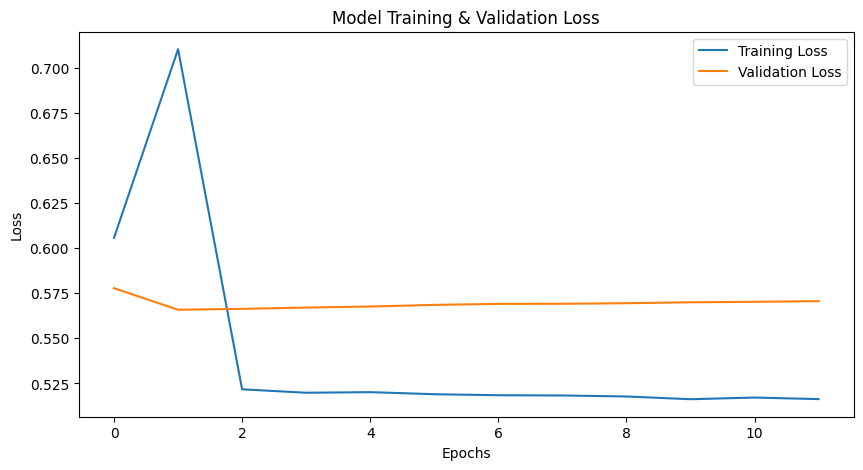

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history.get('val_loss', []), label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Training & Validation Loss')
plt.legend()
plt.show()

In [37]:
# Calculate anomaly threshold from training data
print("\n📌 Calcul du seuil d'anomalie...")
train_errors_subset = calculate_reconstruction_errors(model, normal_train_scaled[:10000], seq_length)
threshold = np.mean(train_errors_subset) + 3 * np.std(train_errors_subset)
print(f"\n ✔ Seuil d'anomalie calculé : {threshold:.4f}")


📌 Calcul du seuil d'anomalie...
Processed 0/9977 sequences
Processed 640/9977 sequences
Processed 1280/9977 sequences
Processed 1920/9977 sequences
Processed 2560/9977 sequences
Processed 3200/9977 sequences
Processed 3840/9977 sequences
Processed 4480/9977 sequences
Processed 5120/9977 sequences
Processed 5760/9977 sequences
Processed 6400/9977 sequences
Processed 7040/9977 sequences
Processed 7680/9977 sequences
Processed 8320/9977 sequences
Processed 8960/9977 sequences
Processed 9600/9977 sequences

 ✔ Seuil d'anomalie calculé : 3.4885


In [ ]:
from tensorflow.keras.models import load_model
model.save('model_LSTM_FR.keras')
# Load the autoencoder model
#model = load_model('model_LSTM_25Epochs.keras')

In [38]:
# Detect anomalies in test data
print("Detecting anomalies...")
test_errors = calculate_reconstruction_errors(model, test_scaled, seq_length)

# Map errors back to original data points
anomaly_scores = np.zeros(len(test_scaled))
for i in range(len(test_errors)):
    idx = i + seq_length - 1
    if idx < len(anomaly_scores):
        anomaly_scores[idx] = test_errors[i]


# For the first seq_length-1 points, copy the first available score
anomaly_scores[:seq_length-1] = anomaly_scores[seq_length-1]

Detecting anomalies...
Processed 0/50570 sequences
Processed 640/50570 sequences
Processed 1280/50570 sequences
Processed 1920/50570 sequences
Processed 2560/50570 sequences
Processed 3200/50570 sequences
Processed 3840/50570 sequences
Processed 4480/50570 sequences
Processed 5120/50570 sequences
Processed 5760/50570 sequences
Processed 6400/50570 sequences
Processed 7040/50570 sequences
Processed 7680/50570 sequences
Processed 8320/50570 sequences
Processed 8960/50570 sequences
Processed 9600/50570 sequences
Processed 10240/50570 sequences
Processed 10880/50570 sequences
Processed 11520/50570 sequences
Processed 12160/50570 sequences
Processed 12800/50570 sequences
Processed 13440/50570 sequences
Processed 14080/50570 sequences
Processed 14720/50570 sequences
Processed 15360/50570 sequences
Processed 16000/50570 sequences
Processed 16640/50570 sequences
Processed 17280/50570 sequences
Processed 17920/50570 sequences
Processed 18560/50570 sequences
Processed 19200/50570 sequences
Proce

In [39]:
# Add results to test dataframe
test_data['anomaly_score'] = anomaly_scores
test_data['anomaly'] = (anomaly_scores > threshold).astype(int)
test_data.rename(columns={'time_stamp': 'timestamp'}, inplace=True)


# Evaluate model
print("\n📌 Évaluation du modèle...")
true_labels = ~test_data['status_type_id'].isin([0, 2])
predicted_labels = test_data['anomaly']
predicted_labels = pd.DataFrame(predicted_labels)


📌 Évaluation du modèle...


<ipython-input-39-2fc16f0120e9>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['anomaly_score'] = anomaly_scores
<ipython-input-39-2fc16f0120e9>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['anomaly'] = (anomaly_scores > threshold).astype(int)
<ipython-input-39-2fc16f0120e9>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returni

In [40]:
# Analyse des résultats avec care_score_processor
df_LSTM_care_score = care_score_processor(test_data, 'anomaly')
df_LSTM_care_score.groupby(['anomaly', 'status_id']).size()

anomaly_results = pd.DataFrame({
    'anomaly': df_LSTM_care_score['anomaly']
}, index=df_LSTM_care_score.index)

care_calculator = CAREScore(omega1=1.0, omega2=1.0, omega3=1.0, omega4=2.0)
scores = care_calculator.calculate_care_score(df_LSTM_care_score, anomaly_results)

[Coverage Debug] TP=67, FN=11428, FP=240, Score=0.0263
[Accuracy Debug] TN=38858, FP=240
[Reliability] Max Criticality: 24, Threshold: 72
[Reliability] Event Detected: 0, Real Event: 1
[Reliability] TP: 0, FN: 1, FP: 0, Score: 0.0000


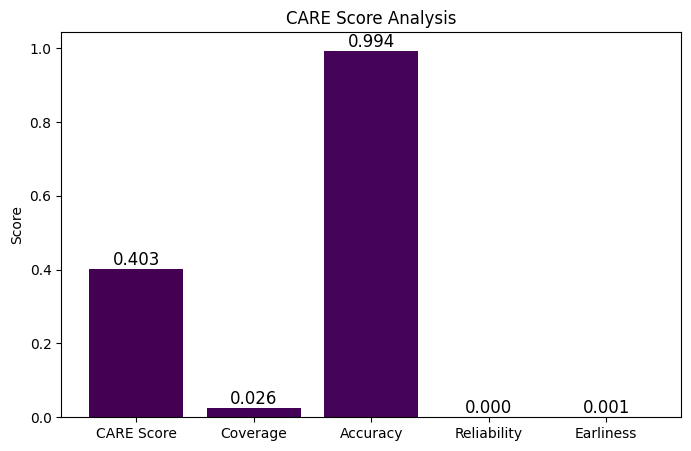

In [41]:
# Extract scores
data = {
    "CARE Score": scores['care'],
    "Coverage": scores['coverage'],
    "Accuracy": scores['accuracy'],
    "Reliability": scores['reliability'],
    "Earliness": scores['earliness']
}

# Plot bar chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.viridis(range(len(data)))  # Use a colormap for consistent coloring
bars = ax.bar(data.keys(), data.values(), color=colors)

# Add value labels on top of bars
for bar, value in zip(bars, data.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.3f}',
            ha='center', va='bottom', fontsize=12, color='black')

ax.set_ylabel("Score")
ax.set_title("CARE Score Analysis")
plt.show()